In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [8]:
print("ZOMATO DATA ANALYSIS PROJECT")
print("=" * 60)

ZOMATO DATA ANALYSIS PROJECT


In [9]:
try:
    df = pd.read_csv("zomato.csv")
except UnicodeDecodeError:
    df = pd.read_csv("zomato.csv", encoding="latin1")

In [10]:
print("\nSTEP 1: FIRST 5 ROWS")
print("-" * 60)
print(df.head())


STEP 1: FIRST 5 ROWS
------------------------------------------------------------
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4

In [11]:
print("\nSTEP 2: DATASET SHAPE")
print("-" * 60)
print(df.shape)

print("\nCOLUMN NAMES")
print("-" * 60)
print(df.columns)

print("\nDATA TYPES")
print("-" * 60)
print(df.dtypes)


STEP 2: DATASET SHAPE
------------------------------------------------------------
(51717, 17)

COLUMN NAMES
------------------------------------------------------------
Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

DATA TYPES
------------------------------------------------------------
url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for tw

In [12]:
print("\nSTEP 3: MISSING VALUES BEFORE CLEANING")
print("-" * 60)
print(df.isnull().sum())


STEP 3: MISSING VALUES BEFORE CLEANING
------------------------------------------------------------
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [13]:
df = df.rename(columns={
    "approx_cost(for two people)": "cost_for_two",
    "listed_in(type)": "service_type",
    "listed_in(city)": "listed_city"
})

In [14]:
df = df.drop(columns=[
    "url",
    "address",
    "phone",
    "reviews_list",
    "menu_item"
], errors="ignore")

In [15]:
df["rate"] = df["rate"].astype(str)

df["rate"] = df["rate"].replace(["NEW", "-", "nan"], np.nan)

df["rate"] = df["rate"].str.replace("/5", "", regex=False)

df["rate"] = df["rate"].str.strip()

df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

In [16]:
df["cost_for_two"] = df["cost_for_two"].astype(str)

df["cost_for_two"] = df["cost_for_two"].str.replace(",", "", regex=False)

df["cost_for_two"] = df["cost_for_two"].replace("nan", np.nan)

df["cost_for_two"] = pd.to_numeric(df["cost_for_two"], errors="coerce")

In [17]:
df["rate"] = df["rate"].fillna(df["rate"].median())

df["cost_for_two"] = df["cost_for_two"].fillna(df["cost_for_two"].median())

df["votes"] = df["votes"].fillna(0)

text_columns = [
    "name",
    "online_order",
    "book_table",
    "location",
    "rest_type",
    "dish_liked",
    "cuisines",
    "service_type",
    "listed_city"
]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

In [18]:
print("\nSTEP 9: SHAPE BEFORE REMOVING DUPLICATES")
print("-" * 60)
print(df.shape)

df = df.drop_duplicates()

print("\nSHAPE AFTER REMOVING DUPLICATES")
print("-" * 60)
print(df.shape)


STEP 9: SHAPE BEFORE REMOVING DUPLICATES
------------------------------------------------------------
(51717, 12)

SHAPE AFTER REMOVING DUPLICATES
------------------------------------------------------------
(51609, 12)


In [19]:
print("\nSTEP 10: MISSING VALUES AFTER CLEANING")
print("-" * 60)
print(df.isnull().sum())

print("\nFINAL DATASET INFO")
print("-" * 60)
df.info()


STEP 10: MISSING VALUES AFTER CLEANING
------------------------------------------------------------
name            0
online_order    0
book_table      0
rate            0
votes           0
location        0
rest_type       0
dish_liked      0
cuisines        0
cost_for_two    0
service_type    0
listed_city     0
dtype: int64

FINAL DATASET INFO
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Int64Index: 51609 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          51609 non-null  object 
 1   online_order  51609 non-null  object 
 2   book_table    51609 non-null  object 
 3   rate          51609 non-null  float64
 4   votes         51609 non-null  int64  
 5   location      51609 non-null  object 
 6   rest_type     51609 non-null  object 
 7   dish_liked    51609 non-null  object 
 8   cuisines      51609 non-null  object 
 9   co

In [20]:
print("\nSTEP 11: ONLINE ORDER COUNT")
print("-" * 60)

online_order_count = df["online_order"].value_counts()

print(online_order_count)


STEP 11: ONLINE ORDER COUNT
------------------------------------------------------------
Yes    30361
No     21248
Name: online_order, dtype: int64


In [21]:
print("\nSTEP 12: TABLE BOOKING COUNT")
print("-" * 60)

table_booking_count = df["book_table"].value_counts()

print(table_booking_count)


STEP 12: TABLE BOOKING COUNT
------------------------------------------------------------
No     45193
Yes     6416
Name: book_table, dtype: int64


In [22]:
print("\nSTEP 13: TOP 10 CUISINES")
print("-" * 60)

top_cuisines = df["cuisines"].value_counts().head(10)

print(top_cuisines)


STEP 13: TOP 10 CUISINES
------------------------------------------------------------
North Indian                           2907
North Indian, Chinese                  2381
South Indian                           1826
Biryani                                 915
Bakery, Desserts                        910
Fast Food                               801
Desserts                                760
Cafe                                    755
South Indian, North Indian, Chinese     726
Bakery                                  651
Name: cuisines, dtype: int64


In [23]:
print("\nSTEP 14: TOP 10 LOCATIONS")
print("-" * 60)

top_locations = df["location"].value_counts().head(10)

print(top_locations)


STEP 14: TOP 10 LOCATIONS
------------------------------------------------------------
BTM                      5109
HSR                      2521
Koramangala 5th Block    2502
JP Nagar                 2234
Whitefield               2140
Indiranagar              2075
Jayanagar                1926
Marathahalli             1843
Bannerghatta Road        1628
Bellandur                1283
Name: location, dtype: int64


In [24]:
print("\nSTEP 15: RATING SUMMARY")
print("-" * 60)

print(df["rate"].describe())


STEP 15: RATING SUMMARY
------------------------------------------------------------
count    51609.000000
mean         3.700114
std          0.395393
min          1.800000
25%          3.500000
50%          3.700000
75%          3.900000
max          4.900000
Name: rate, dtype: float64


In [25]:
print("\nSTEP 16: COST SUMMARY")
print("-" * 60)

print(df["cost_for_two"].describe())


STEP 16: COST SUMMARY
------------------------------------------------------------
count    51609.000000
mean       554.136391
std        437.305803
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: cost_for_two, dtype: float64


In [26]:
print("\nSTEP 17: COST VS RATING CORRELATION")
print("-" * 60)

cost_rating_correlation = df["cost_for_two"].corr(df["rate"])

print(cost_rating_correlation)


STEP 17: COST VS RATING CORRELATION
------------------------------------------------------------
0.36396883702378785


In [27]:
print("\nSTEP 18: ONLINE ORDER VS RATING")
print("-" * 60)

online_rating = df.groupby("online_order")["rate"].mean()

print(online_rating)


STEP 18: ONLINE ORDER VS RATING
------------------------------------------------------------
online_order
No     3.67180
Yes    3.71993
Name: rate, dtype: float64


In [28]:
print("\nSTEP 19: TABLE BOOKING VS RATING")
print("-" * 60)

booking_rating = df.groupby("book_table")["rate"].mean()

print(booking_rating)


STEP 19: TABLE BOOKING VS RATING
------------------------------------------------------------
book_table
No     3.638586
Yes    4.133510
Name: rate, dtype: float64


In [29]:
print("\nSTEP 20: ONLINE ORDER VS COST")
print("-" * 60)

online_cost = df.groupby("online_order")["cost_for_two"].mean()

print(online_cost)


STEP 20: ONLINE ORDER VS COST
------------------------------------------------------------
online_order
No     595.758613
Yes    525.007279
Name: cost_for_two, dtype: float64


In [30]:
print("\nSTEP 21: TABLE BOOKING VS COST")
print("-" * 60)

booking_cost = df.groupby("book_table")["cost_for_two"].mean()

print(booking_cost)


STEP 21: TABLE BOOKING VS COST
------------------------------------------------------------
book_table
No      452.329454
Yes    1271.243766
Name: cost_for_two, dtype: float64


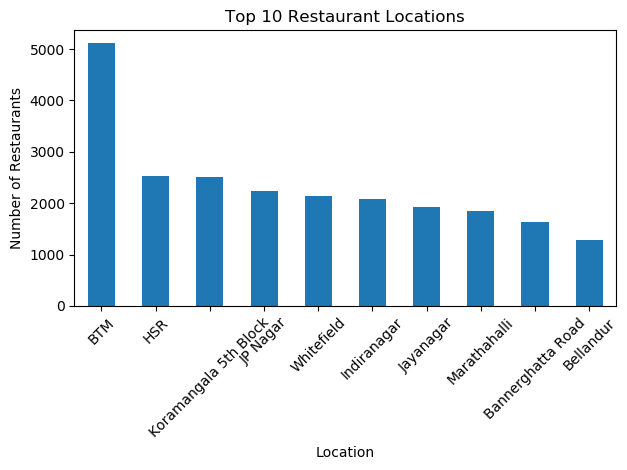

In [31]:
top_locations.plot(kind="bar")

plt.xlabel("Location")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Restaurant Locations")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

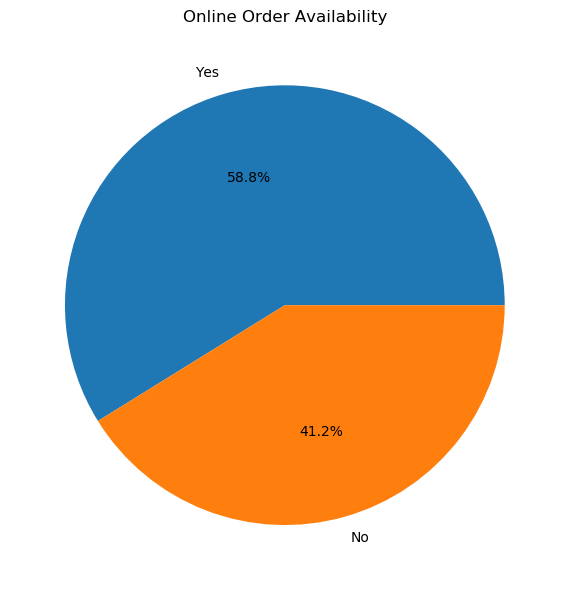

In [32]:
plt.figure(figsize=(6, 6))

online_order_count.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Online Order Availability")
plt.tight_layout()

plt.show()

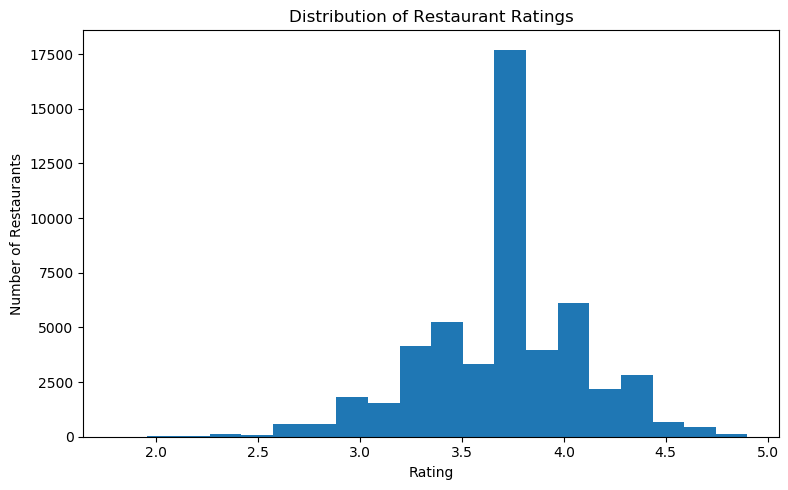

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(df["rate"], bins=20)

plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant Ratings")
plt.tight_layout()

plt.show()

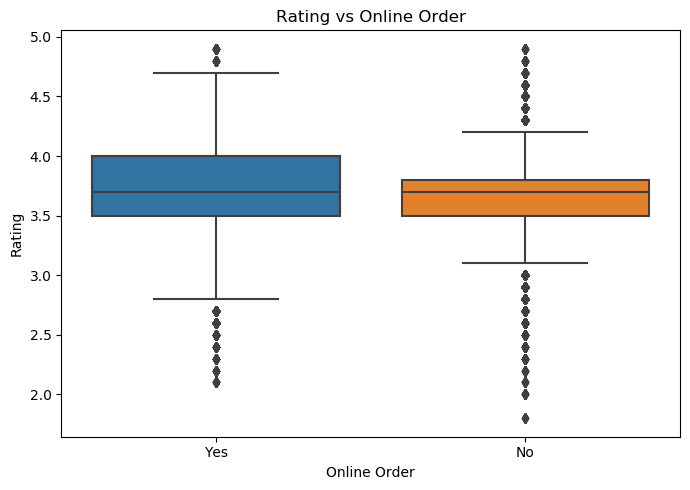

In [34]:
plt.figure(figsize=(7, 5))

sns.boxplot(x="online_order", y="rate", data=df)

plt.xlabel("Online Order")
plt.ylabel("Rating")
plt.title("Rating vs Online Order")
plt.tight_layout()

plt.show()

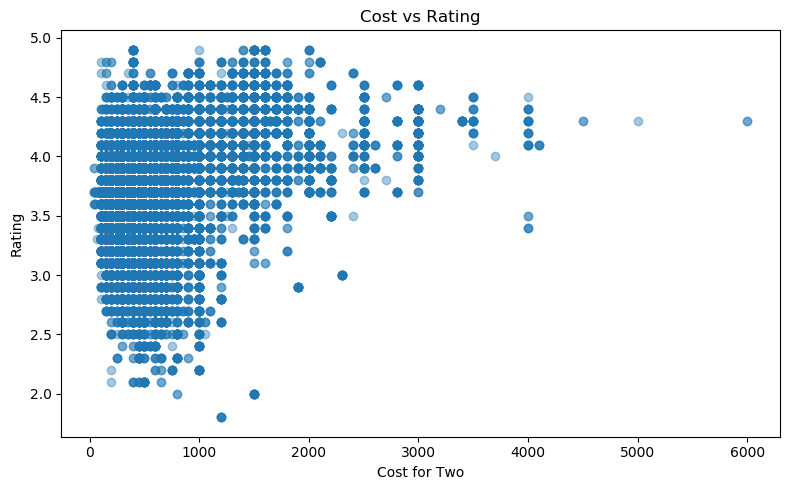

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(df["cost_for_two"], df["rate"], alpha=0.4)

plt.xlabel("Cost for Two")
plt.ylabel("Rating")
plt.title("Cost vs Rating")
plt.tight_layout()

plt.show()

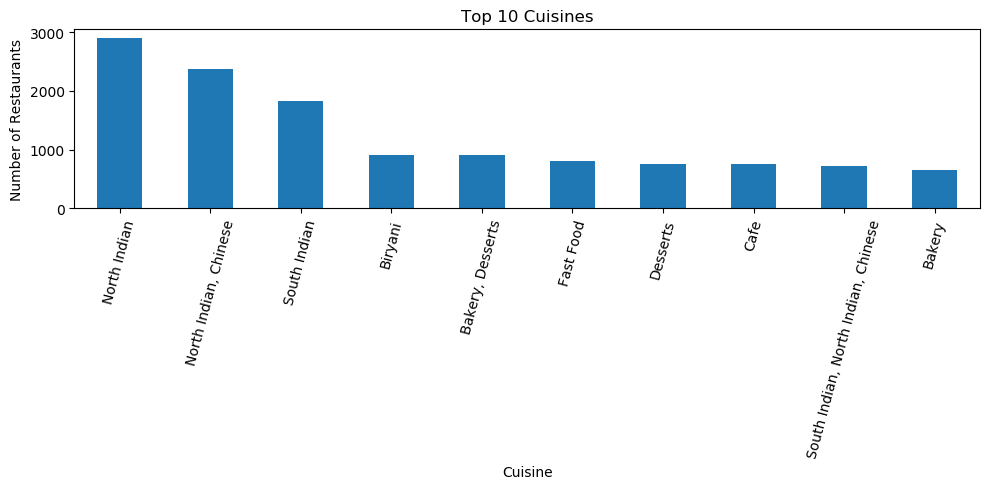

In [36]:
plt.figure(figsize=(10, 5))

top_cuisines.plot(kind="bar")

plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Cuisines")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [37]:
print("\nSTEP 28: CORRELATION ANALYSIS")
print("-" * 60)

numeric_data = df[["rate", "votes", "cost_for_two"]]

correlation_table = numeric_data.corr()

print(correlation_table)


STEP 28: CORRELATION ANALYSIS
------------------------------------------------------------
                  rate     votes  cost_for_two
rate          1.000000  0.426917      0.363969
votes         0.426917  1.000000      0.380182
cost_for_two  0.363969  0.380182      1.000000


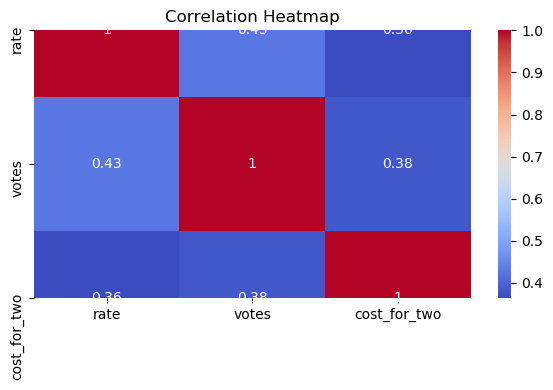

In [38]:
plt.figure(figsize=(6, 4))

sns.heatmap(correlation_table, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

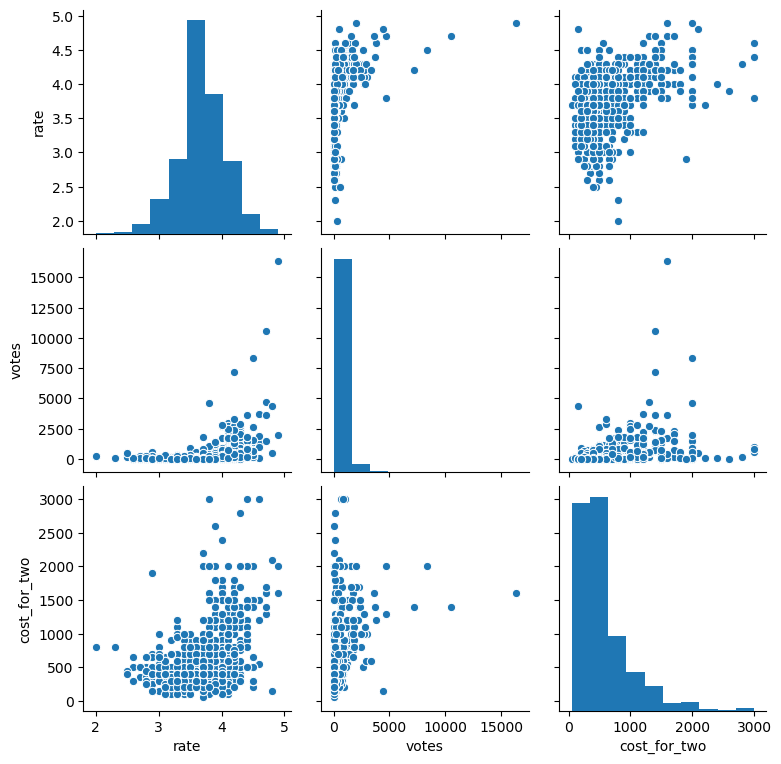

In [39]:
sample_data = numeric_data.sample(1000, random_state=42)

sns.pairplot(sample_data)

plt.show()

In [40]:
print("\nSTEP 31: RATING PREDICTION MODEL")
print("-" * 60)

model_data = df[["votes", "cost_for_two", "rate"]].copy()

X = model_data[["votes", "cost_for_two"]]

y = model_data["rate"]


STEP 31: RATING PREDICTION MODEL
------------------------------------------------------------


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [43]:
y_pred = model.predict(X_test)

In [44]:
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error:")
print(mae)

print("\nR2 Score:")
print(r2)


Mean Absolute Error:
0.2567152866844836

R2 Score:
0.23230447667410403


In [45]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
        Feature  Coefficient
0         votes     0.000167
1  cost_for_two     0.000212


In [46]:
print("\nSTEP 37: INSIGHTS")
print("=" * 60)

highest_restaurant_location = df["location"].value_counts().idxmax()

most_common_cuisine = df["cuisines"].value_counts().idxmax()

average_rating = df["rate"].mean()

average_cost = df["cost_for_two"].mean()


print("\nInsight 1:")
print("The location with the most restaurants is", highest_restaurant_location)

print("\nInsight 2:")
print("The most common cuisine is", most_common_cuisine)

print("\nInsight 3:")
print("The average restaurant rating is", round(average_rating, 2))

print("\nInsight 4:")
print("The average cost for two people is", round(average_cost, 2))

print("\nInsight 5:")
print("Average rating based on online order:")
print(online_rating)

print("\nInsight 6:")
print("Average rating based on table booking:")
print(booking_rating)


STEP 37: INSIGHTS

Insight 1:
The location with the most restaurants is BTM

Insight 2:
The most common cuisine is North Indian

Insight 3:
The average restaurant rating is 3.7

Insight 4:
The average cost for two people is 554.14

Insight 5:
Average rating based on online order:
online_order
No     3.67180
Yes    3.71993
Name: rate, dtype: float64

Insight 6:
Average rating based on table booking:
book_table
No     3.638586
Yes    4.133510
Name: rate, dtype: float64


In [47]:
print("\nSTEP 38: BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("\nRecommendation 1:")
print("Restaurants should offer online ordering because it gives customers more convenience.")

print("\nRecommendation 2:")
print("New restaurants can focus on popular locations where restaurant demand is high.")

print("\nRecommendation 3:")
print("Restaurants should focus on popular cuisines because they already have strong customer interest.")

print("\nRecommendation 4:")
print("Restaurants can improve ratings by improving food quality, service quality, and customer experience.")

print("\nRecommendation 5:")
print("Table booking can be useful for restaurants that want to attract dine-in customers.")


STEP 38: BUSINESS RECOMMENDATIONS

Recommendation 1:
Restaurants should offer online ordering because it gives customers more convenience.

Recommendation 2:
New restaurants can focus on popular locations where restaurant demand is high.

Recommendation 3:
Restaurants should focus on popular cuisines because they already have strong customer interest.

Recommendation 4:
Restaurants can improve ratings by improving food quality, service quality, and customer experience.

Recommendation 5:
Table booking can be useful for restaurants that want to attract dine-in customers.
